# **โครงการแมชชีนเลิร์นนิ่งแบบ End-to-end**



In [20]:
print("Welcome to Machine Learning!")

Welcome to Machine Learning!


โครงการนี้จำเป็นต้องใช้ Python 3.7 ขึ้นไป

In [21]:
import sys

assert sys.version_info >= (3, 7)

import warnings
warnings.filterwarnings('ignore')

โครงการนี้ยังจำเป็นต้องใช้ Scikit-Learn เวอร์ชัน 1.0.1 ขึ้นไปด้วย

In [22]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

# 1. ดึงข้อมูล


ยินดีต้อนรับสู่ บริษัทแมชชีนเลิร์นนิง เฮ้าส์ซิ่ง คอร์ปอเรชั่น! งานของคุณคือการทำนายมูลค่าบ้านเฉลี่ยในเขตแคลิฟอร์เนีย โดยพิจารณาจากคุณลักษณะต่างๆ ของเขตเหล่านั้น



## 1.1 โหลดข้อมูล

In [38]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

## 1.2 วิเคราะห์ข้อมูล
ก่อนเริ่มวิเคราะห์ข้อมูล เราควร ดูโครงสร้างข้อมูลเบื้องต้น เพื่อทำความเข้าใจข้อมูลที่มี

In [39]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [40]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [41]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [42]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


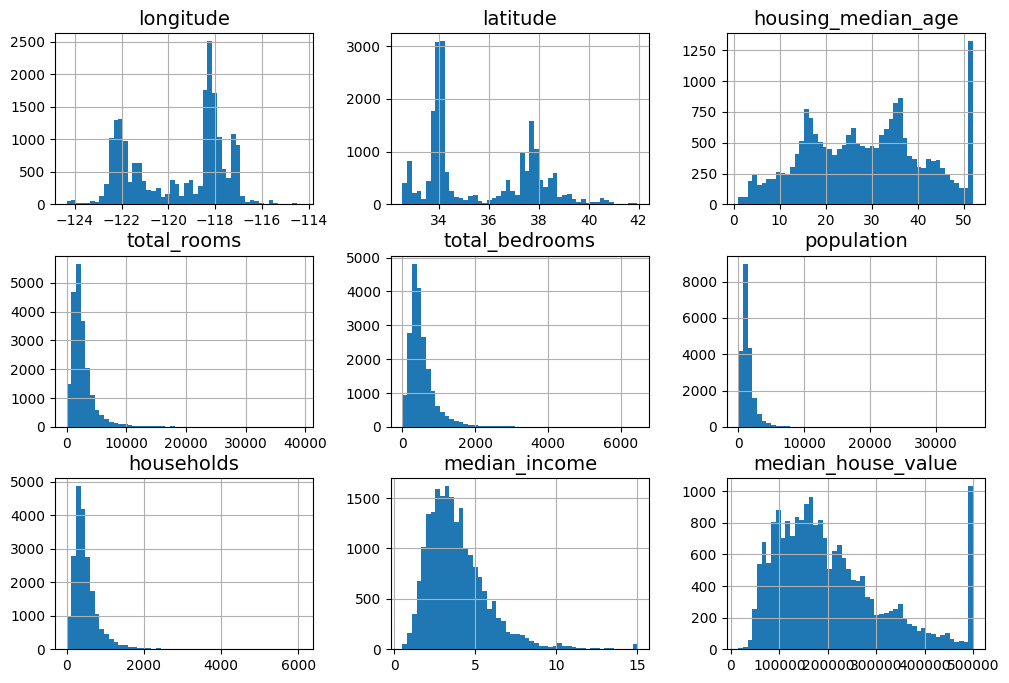

In [43]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
plt.show()

## 1.3 สร้าง Test Set

### 1.3.1 สร้าง Test Set (อย่างง่าย)

In [44]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [45]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)
len(train_set)

16512

In [46]:
len(test_set)

4128

เพื่อให้ผลลัพธ์ของโน้ตบุ๊กนี้เหมือนเดิมทุกครั้งที่รัน เราจำเป็นต้องตั้งค่า random seed

In [47]:
np.random.seed(42)

### 1.3.2 ตัวอย่าง sample ที่ไม่ดี


เพื่อหาความน่าจะเป็นที่กลุ่มตัวอย่างสุ่มขนาด 1,000 คน จะมีสัดส่วนเพศหญิงน้อยกว่า 48.5% หรือมากกว่า 53.5% ในขณะที่สัดส่วนเพศหญิงในประชากรทั้งหมดอยู่ที่ 51.1% เราใช้ [การแจกแจงแบบทวินาม] `Binom`
วิธี cdf() ของการแจกแจงแบบทวินาม ให้ความน่าจะเป็นที่จำนวนเพศหญิงจะเท่ากับหรือต่ำกว่าค่าที่กำหนด

In [48]:
# extra code – shows how to compute the 10.7% proba of getting a bad sample

from scipy.stats import binom

sample_size = 1000
ratio_female = 0.511
proba_too_small = binom(sample_size, ratio_female).cdf(485 - 1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(535)
print(proba_too_small + proba_too_large)

0.10736798530929942


In [49]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

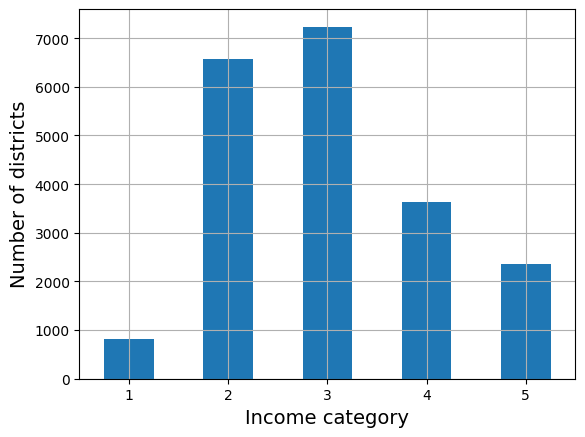

In [50]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

### 1.3.3 สร้าง Test Set (แบบสมดุล)

In [51]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [52]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [53]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# 2. ค้นพบและมองเห็นภาพข้อมูลเพื่อค้นหาข้อมูลเชิงลึก

In [54]:
housing = strat_train_set.copy()

## 2.1 การมองเห็นภาพข้อมูลทางภูมิศาสตร์


### 2.1.1 พล็อตอย่างง่าย

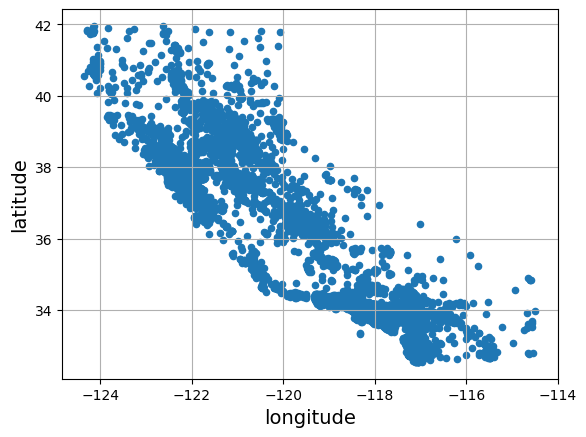

In [55]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

### 2.1.2 พล็อตอย่างง่าย + alpha

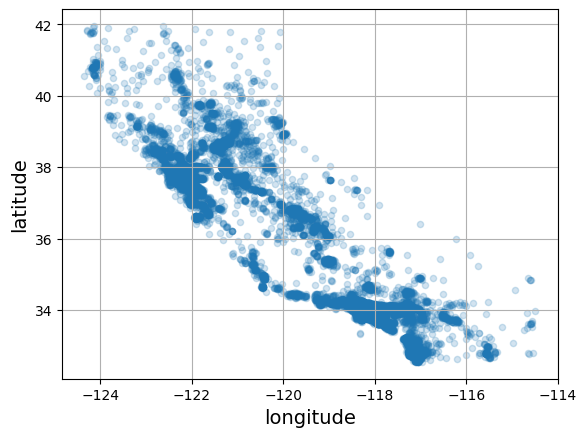

In [56]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

### 2.1.3 พล็อตด้วยสี

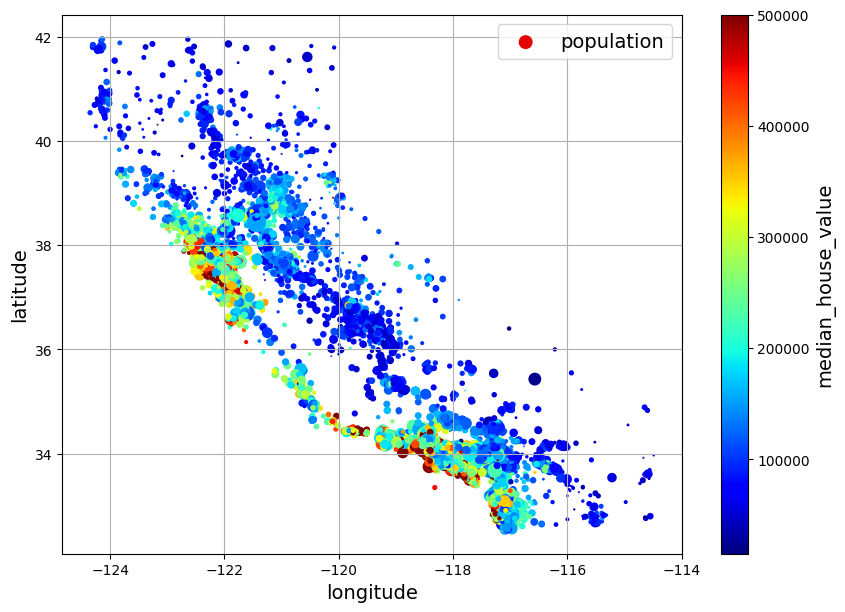

In [57]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

## 2.2 ค้นหาความสัมพันธ์


หมายเหตุ: ตั้งแต่ Pandas 2.0.0 ขึ้นไป อาร์กิวเมนต์ `numeric_only` จะมีค่าเริ่มต้นเป็น `False` ดังนั้นเราต้องตั้งค่าเป็น `True` อย่างชัดเจนเพื่อหลีกเลี่ยงข้อผิดพลาด

In [58]:
corr_matrix = housing.corr(numeric_only=True)

In [59]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


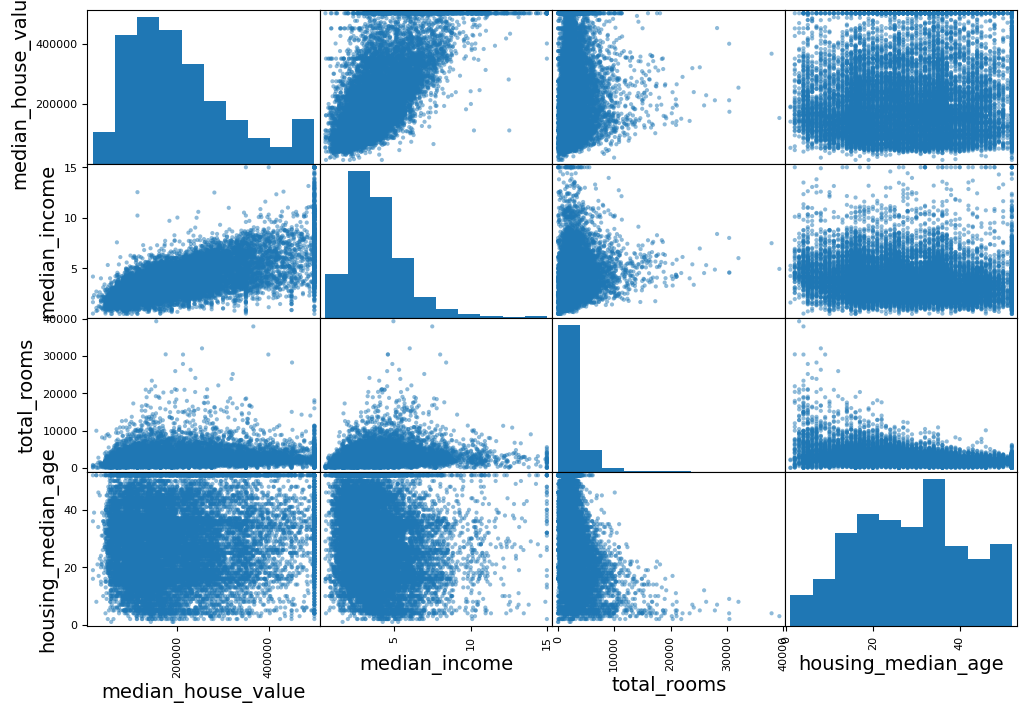

In [60]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

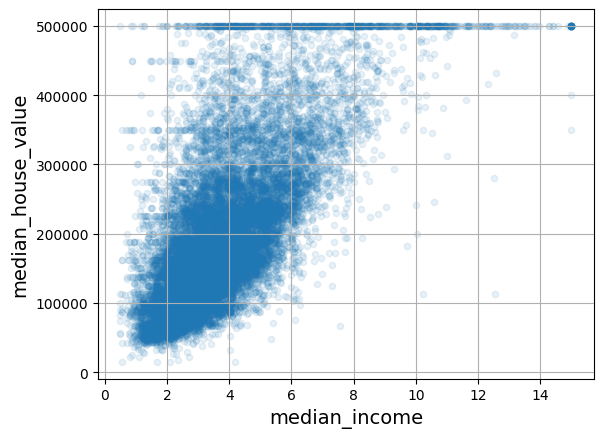

In [61]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.show()

## 2.3 ทดลองกับการรวมคุณลักษณะ (features)

In [62]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [63]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


# 3. เตรียมข้อมูลสำหรับอัลกอริทึมแมชชีนเลิร์นนิง

ให้เรากลับไปใช้ชุดฝึกอบรมดั้งเดิม และแยกคอลัมน์เป้าหมายออกจากชุดข้อมูล (โปรดทราบว่าฟังก์ชัน `strat_train_set.drop() `จะสร้างสำเนาของ `strat_train_set `โดยไม่รวมคอลัมน์ที่ระบุไว้ ไม่ได้แก้ไข `strat_train_set` ดั้งเดิม เว้นแต่คุณจะกำหนดค่า `inplace=True`

In [64]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()
housing_test = strat_test_set.drop("median_house_value", axis=1)
housing_labels_test = strat_test_set["median_house_value"].copy()

## 3.1 ทำความสะอาดข้อมูล (NaN)

มี 3 ตัวเลือกสำหรับการจัดการค่า NaN

```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1

housing.drop("total_bedrooms", axis=1)       # option 2

median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```


In [65]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


### 3.1.1 ตัวเลือกที่ 1

In [66]:
housing_option1 = housing.copy()

housing_option1.dropna(subset=["total_bedrooms"], inplace=True)  # option 1

housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


### 3.1.2 ตัวเลือกที่ 2

In [67]:
housing_option2 = housing.copy()

housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # option 2

housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


### 3.1.3 ตัวเลือกที่ 3

In [68]:
housing_option3 = housing.copy()

median = housing["total_bedrooms"].median()
housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3

housing_option3.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN


### 3.1.4 ตัวเลือกที่ 4: Imputer (ใช้ตัวนี้)

In [69]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [70]:
housing_num = housing.select_dtypes(include=[np.number])

#### 3.1.4.1 การ fit และ transform

In [71]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [72]:
X = imputer.transform(housing_num)
print(imputer.feature_names_in_)
print(imputer.strategy)

['longitude' 'latitude' 'housing_median_age' 'total_rooms'
 'total_bedrooms' 'population' 'households' 'median_income']
median


#### 3.1.4.2 แปลงเป็น dataframe คืน

In [73]:
housing_num.index

Index([13096, 14973,  3785, 14689, 20507,  1286, 18078,  4396, 18031,  6753,
       ...
       11877, 17004,  1894,  6234,  7071, 14207, 13105, 19301, 19121, 19888],
      dtype='int64', length=16512)

In [74]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


## 3.2 ลบค่า Outliers

ตอนนี้เรามาลองลบค่าผิดปกติออกไปกัน:

In [75]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)
print(outlier_pred)

[-1  1  1 ...  1  1  1]


In [76]:
housing = housing.iloc[outlier_pred == 1]
housing_labels = housing_labels.iloc[outlier_pred == 1]

## 3.3 การจัดการกับข้อความและคุณลักษณะเชิงหมวดหมู่

ตอนนี้เรามาเตรียมข้อมูลป้อนเข้าแบบหมวดหมู่กัน, `ocean_proximity`:




In [77]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN


### 3.3.1 การใช้ OrdinalEncoder

In [78]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

print(ordinal_encoder.categories_)
print(housing_cat_encoded[:8])

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]
[[0.]
 [1.]
 [1.]
 [4.]
 [1.]
 [0.]
 [3.]
 [0.]]


### 3.3.2 การใช้ OneHotEncoder (ใช้ตัวนี้)

#### 3.3.2.1 Sparse array (True)

In [79]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

คลาส `OneHotEncoder` คืนค่าเป็นอาร์เรย์แบบเบาบาง (sparse array) ตามค่าเริ่มต้น แต่เราสามารถแปลงเป็นอาร์เรย์แบบหนาแน่น (dense array) ได้ตามต้องการโดยเรียกใช้เมธอด `toarray()`

In [80]:
housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

#### 3.3.2.2 Sparse array (False)

In [81]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [82]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [83]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

#### 3.3.2.3 จัดการกับ Unknown

In [84]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


In [85]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

#### 3.3.2.4 แปลงเป็น dataframe คืน

In [86]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [87]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
                         columns=cat_encoder.get_feature_names_out(),
                         index=df_test_unknown.index)
df_output.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0


## 3.4 การใช้ Feature Scaling


### 3.4.1 Min-Max และ StandardScaler

In [88]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [89]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

### 3.4.2 การใช้ log

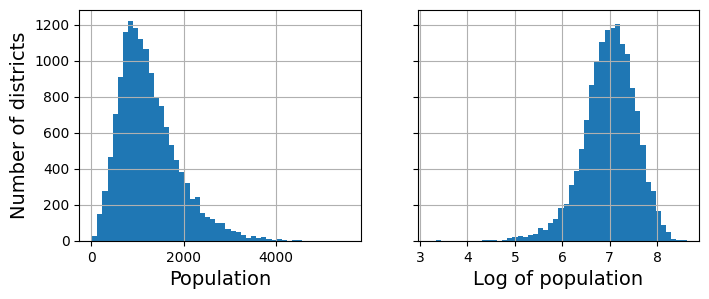

In [90]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
plt.show()

### 3.4.3 การใช้ rbf kernel

In [91]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

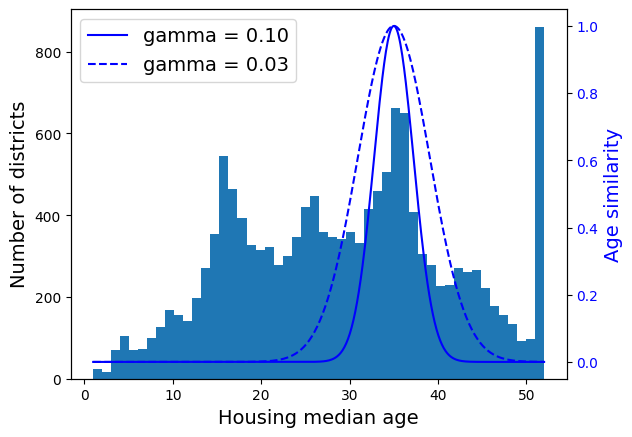

In [92]:
ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
plt.show()

# 4. การใช้ Custom Transformers

## 4.1 สร้าง transformers แบบ Function :

### 4.1.1 สร้าง log

In [93]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

### 4.1.2 สร้าง rbf

In [94]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])
print(age_simil_35)

[[8.20849986e-02]
 [6.70320046e-01]
 [8.48904403e-15]
 ...
 [9.55316054e-22]
 [6.70320046e-01]
 [3.03539138e-04]]


In [95]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])
print(sf_simil)

[[0.05258419]
 [0.94864161]
 [0.01192662]
 ...
 [0.00388525]
 [0.05038518]
 [0.99868067]]


### 4.1.3 สร้าง ratio

In [96]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

## 4.2 สร้าง transformer แบบ Class

### 4.2.1 สร้าง StandardScaler (ตัวอย่าง)

In [97]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X):
        check_is_fitted(self)  # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

### 4.2.2 สร้าง K-means Clustering

In [98]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init='auto',
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

#### 4.2.2.1 ใช้งาน Cluster-Similarity

In [99]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]],
                                           sample_weight=housing_labels)

In [100]:
similarities[:3].round(2)

array([[0.  , 0.99, 0.  , 0.  , 0.04, 0.03, 0.  , 0.59, 0.73, 0.26],
       [0.31, 0.  , 0.  , 0.5 , 0.  , 0.  , 0.7 , 0.  , 0.  , 0.  ],
       [0.  , 0.21, 0.  , 0.  , 0.46, 0.  , 0.  , 0.02, 0.51, 0.88]])

#### 4.2.2.2 พล็อตภาพ Cluster-Similarity

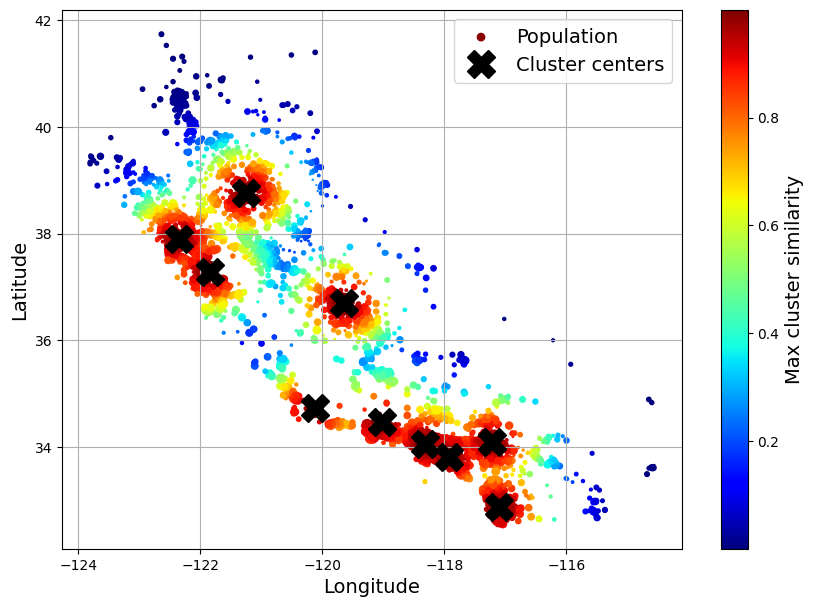

In [101]:
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
plt.show()

## 4.3 สร้าง Transformer แบบ Pipelines

### 4.3.1 สร้าง pipeline (เชิงตัวเลข)
ตอนนี้เรามาสร้างไปป์ไลน์เพื่อเตรียมการข้อมูลเชิงตัวเลขกัน

In [102]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

หรือ

In [103]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [104]:
from sklearn import set_config

set_config(display='diagram')

print(num_pipeline.steps)
print('-'*30)
print(num_pipeline.named_steps["simpleimputer"])
print('-'*30)

num_pipeline

[('simpleimputer', SimpleImputer(strategy='median')), ('standardscaler', StandardScaler())]
------------------------------
SimpleImputer(strategy='median')
------------------------------


Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [105]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [106]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

In [107]:
df_housing_num_prepared.head(2)  # extra code

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942


In [108]:
num_pipeline.set_params(simpleimputer__strategy="median")

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

### 4.3.2 สร้าง pipeline (เชิง Catagory)

In [109]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

หรือ **จาก pipeline ของเราคือ**
```python

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))
)
```

In [110]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [111]:
housing_prepared = preprocessing.fit_transform(housing)

In [112]:
# extra code – shows that we can get a DataFrame out if we want
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)
housing_prepared_fr.head(2)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
14973,0.595527,-0.692801,0.875904,-0.257539,-0.479342,-0.911423,-0.367756,1.383990,1.0,0.0,0.0,0.0,0.0
3785,-1.273032,1.361924,0.292345,-1.043780,-1.077558,-1.073350,-1.092179,-0.804668,0.0,1.0,0.0,0.0,0.0


# 5. สรุป pre-processing pipeline

In [113]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

In [114]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(14448, 24)

In [115]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

# 6. เลือกโมเดลและฝึกฝน

In [116]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,precision_score,recall_score,f1_score,precision_recall_curve,confusion_matrix
from scipy.stats import randint,uniform

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

## 6.1 Linear Regression

### 6.1.1 ฝึกโมเดล (อย่างง่าย)

In [117]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7b5...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b50a002c0d0>)])),
                ('linearregression', LinearRegression())])

### 6.1.2 ฝึกโมเดล(แบบ tune parameters)

In [118]:
param_lin = {'linearregression__fit_intercept': [True, False],
             'linearregression__positive': [True, False]}

linreg_search = RandomizedSearchCV(lin_reg,
                                   param_distributions=param_lin,
                                   n_iter=10,
                                   cv=3,
                                   scoring='neg_root_mean_squared_error',
                                   random_state=42)

linreg_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_na...
                                                                                               ('onehotencoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x7b50a002c0d0>)])),
                                             ('linearregression',
                                              LinearRegression())]),
                   param_distributions={'linearregression__fit_intercept': [True,
                                                                            False],
                                        'linearregression__positive': [True,
                                                                       False]},
                   random_state=42, scoring='neg_root_mean_squared_error')

ลองใช้ไปป์ไลน์การเตรียมข้อมูลทั้งหมดกับตัวอย่างข้อมูลฝึกสักสองสามตัว:

### 6.1.3 คาดการณ์ (Trainset)

In [119]:
housing_predictions = lin_reg.predict(housing)
print(f'with out tune [:5]:{housing_predictions[:5].round(-2)}')  # -2 = rounded to the nearest hundred
print(housing.shape)
housing_predictions_t = linreg_search.predict(housing)
print(f'with tune [:5]:{housing_predictions_t[:5].round(-2)}')  # -2 = rounded to the nearest hundred


with out tune [:5]:[383000. 117900. 103800. 335900. 188100.]
(14448, 9)
with tune [:5]:[383000. 117900. 103800. 335900. 188100.]


เปรียบเทียบกับค่าจริง

In [120]:
housing_labels.iloc[:5].values

array([483800., 101700.,  96100., 361800.,  92600.])

### 6.1.4 ประเมินโมเดล (Trainset)

In [121]:
# extra code – computes the error ratios
error_ratios = housing_predictions[:5].round(-2) / housing_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-20.8%, 15.9%, 8.0%, -7.2%, 103.1%


In [122]:
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions)
print(f'mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions_t)
print(f'mae :{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')

mae:48925.01, mse:4334447302.23, rmse:65836.52, r_squared:0.65
mae :48925.01, mse:4334447302.23, rmse:65836.52, r_squared:0.65


### 6.1.5 ประเมินโมเดล (Testset)

In [123]:
housing_predictions_test = lin_reg.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_test)
print(f'mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
print(housing_predictions_test.shape)

housing_predictions_test_t = linreg_search.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_test_t)
print(f'mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')


mae:59596.69, mse:176228244274.95, rmse:419795.48, r_squared:-12.17
(4128,)
mae:59596.69, mse:176228244274.95, rmse:419795.48, r_squared:-12.17


## 6.2 Ridge , Lasso, Elastic-Net
(Linear Regression + การลงโทษ)

### 6.2.1 ฝึกโมเดล (อย่างง่าย)

In [124]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

ridge_reg = make_pipeline(preprocessing, Ridge())
ridge_reg.fit(housing, housing_labels)

lasso_reg = make_pipeline(preprocessing, Lasso())
lasso_reg.fit(housing, housing_labels)

elastic_reg = make_pipeline(preprocessing, ElasticNet())
elastic_reg.fit(housing, housing_labels)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7b5...
                                                   'households',
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b50a002c0d0>)])),
                ('elasticnet', ElasticNet())])

### 6.2.2 ฝึกโมเดล(แบบ tune parameters)

In [125]:
from sklearn.model_selection import RandomizedSearchCV

param_ridge = {'ridge__alpha': randint(low=1,high=1000),
               'ridge__solver':['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga','lbfgs'] }

param_lasso = {'lasso__selection': ['cyclic', 'random'],
               'lasso__alpha': randint(low=1,high=1000)}

param_elas = {'elasticnet__selection': ['cyclic', 'random'],
              'elasticnet__alpha': randint(low=1,high=1000)}


ridge_search = RandomizedSearchCV(ridge_reg,
                                  param_distributions=param_ridge,
                                  n_iter=10,
                                  cv=5,
                                  scoring='neg_root_mean_squared_error',
                                  random_state=42)

lasso_search = RandomizedSearchCV(lasso_reg,
                                  param_distributions=param_lasso,
                                  n_iter=10,
                                  cv=5,
                                  scoring='neg_root_mean_squared_error',
                                  random_state=42)

elastic_search = RandomizedSearchCV(elastic_reg,
                                  param_distributions=param_elas,
                                  n_iter=10,
                                  cv=5,
                                  scoring='neg_root_mean_squared_error',
                                  random_state=42)



ridge_search.fit(housing, housing_labels)
lasso_search.fit(housing, housing_labels)
elastic_search.fit(housing, housing_labels)



RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_na...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x7b50a002c0d0>)])),
                                             ('elasticnet', ElasticNet())]),
                   param_distributions={'elasticnet__alpha': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b509e2cbd30>,
                                        'elasticnet__selection': ['cyclic',
                                                                  'random']},
                   random_state=42, scoring='neg_root_mean_squared_error')

### 6.2.3 คาดการณ์ (Trainset)

In [126]:
# Ridge
housing_predictions_r = ridge_reg.predict(housing)
print(f'Ridge with out tune [:5]:{housing_predictions_r[:5].round(-2)}')  # -2 = rounded to the nearest hundred
housing_predictions_r_t = ridge_search.predict(housing)
print(f'Ridge with tune [:5]:{housing_predictions_r_t[:5].round(-2)}')  # -2 = rounded to the nearest hundred
print(housing_predictions_r.shape)
# Lasso
housing_predictions_l = lasso_reg.predict(housing)
print(f'Lasso with out tune [:5]:{housing_predictions_l[:5].round(-2)}')  # -2 = rounded to the nearest hundred
housing_predictions_l_t = lasso_search.predict(housing)
print(f'Lasso with tune [:5]:{housing_predictions_l_t[:5].round(-2)}')  # -2 = rounded to the nearest hundred


# Elastic Net
housing_predictions_e = elastic_reg.predict(housing)
print(f'Elastic with out tune [:5]:{housing_predictions_e[:5].round(-2)}')  # -2 = rounded to the nearest hundred
housing_predictions_e_t = elastic_search.predict(housing)
print(f'Elastic with tune [:5]:{housing_predictions_e_t[:5].round(-2)}')  # -2 = rounded to the nearest hundred


print(f'real value [:5]: {housing_labels.iloc[:5].values}')

Ridge with out tune [:5]:[382800. 117700. 103600. 336000. 188100.]
Ridge with tune [:5]:[371800. 112800.  97700. 333100. 188200.]
(14448,)
Lasso with out tune [:5]:[383000. 117900. 103800. 335900. 188100.]
Lasso with tune [:5]:[371800. 117600.  96300. 336400. 187300.]
Elastic with out tune [:5]:[307100. 146900. 148000. 258800. 209100.]
Elastic with tune [:5]:[207700. 201500. 203000. 205700. 204500.]
real value [:5]: [483800. 101700.  96100. 361800.  92600.]


### 6.2.4 ประเมินโมเดล (Trainset)

In [127]:
# Ridge
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions_r)
print(f'Ridge with out tune \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions_r_t)
print(f'Ridge with tune \n mae :{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
print('-'*30)
# Lasso
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions_l)
print(f'Lasso with out tune \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions_l_t)
print(f'Lasso with tune \n mae :{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
print('-'*30)

# Elastic
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions_e)
print(f'Elastic with out tune \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
mae, mse, rmse, r_squared =  evaluation(housing_labels,housing_predictions_e_t)
print(f'Elastic with tune \n mae :{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
print('-'*30)



Ridge with out tune 
 mae:48935.89, mse:4335154235.36, rmse:65841.89, r_squared:0.65
Ridge with tune 
 mae :49557.46, mse:4426868701.49, rmse:66534.72, r_squared:0.64
------------------------------
Lasso with out tune 
 mae:48925.49, mse:4334456851.09, rmse:65836.59, r_squared:0.65
Lasso with tune 
 mae :50004.10, mse:4491875863.90, rmse:67021.46, r_squared:0.64
------------------------------
Elastic with out tune 
 mae:58161.50, mse:6025058959.10, rmse:77621.25, r_squared:0.52
Elastic with tune 
 mae :86142.18, mse:12048490585.48, rmse:109765.62, r_squared:0.03
------------------------------


### 6.2.5 ประเมินโมเดล (Testset)

In [128]:
# prompt: evaluate with testset

# ### 6.2.5 ประเมินโมเดล (Testset)
# Ridge
housing_predictions_r_test = ridge_reg.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_r_test)
print(f'Ridge with out tune (testset) \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
housing_predictions_r_test_t = ridge_search.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_r_test_t)
print(f'Ridge with tune (testset) \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
print('-'*30)

# Lasso
housing_predictions_l_test = lasso_reg.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_l_test)
print(f'Lasso with out tune (testset) \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')

housing_predictions_l_test_t = lasso_search.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_l_test_t)
print(f'Lasso with tune (testset) \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
print('-'*30)

# Elastic Net
housing_predictions_e_test = elastic_reg.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_e_test)
print(f'Elastic with out tune (testset) \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')

housing_predictions_e_test_t = elastic_search.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_e_test_t)
print(f'Elastic with tune (testset) \n mae:{mae:.2f}, mse:{mse:.2f}, rmse:{rmse:.2f}, r_squared:{r_squared:.2f}')
print('-'*30)

Ridge with out tune (testset) 
 mae:59494.17, mse:173069433797.40, rmse:416016.15, r_squared:-11.93
Ridge with tune (testset) 
 mae:55841.21, mse:42760673858.81, rmse:206786.54, r_squared:-2.19
------------------------------
Lasso with out tune (testset) 
 mae:59578.88, mse:175636937488.75, rmse:419090.61, r_squared:-12.12
Lasso with tune (testset) 
 mae:55995.21, mse:38795040267.12, rmse:196964.57, r_squared:-1.90
------------------------------
Elastic with out tune (testset) 
 mae:67442.89, mse:108595136148.44, rmse:329537.76, r_squared:-7.11
Elastic with tune (testset) 
 mae:89650.10, mse:13168598672.83, rmse:114754.51, r_squared:0.02
------------------------------


## 6.3 Tree, Random Forest

### 6.3.1 ฝึกโมเดล (อย่างง่าย)

In [129]:
# !pip uninstall -y scikit-learn
# !pip install scikit-learn==1.5.2

In [130]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb


tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=20))
tree_reg.fit(housing, housing_labels)

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_reg.fit(housing, housing_labels)

# xgboost_reg = make_pipeline(preprocessing, XGBRegressor(random_state=42))
# xgboost_reg.fit(housing, housing_labels)



Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7b5...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b50a002c0d0>)])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

### 6.3.2 ฝึกโมเดล(แบบ tune parameters)

**โน๊ต** โค้ดนี้ใช้เวลา 30 นาทีในการรัน

ลด `n_iter=10` เป็น `n_iter=2`, และ `cv=3` เป็น `cv=1` หากต้องการความเร็ว

In [131]:
param_tree = {'decisiontreeregressor__criterion' :['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
              'decisiontreeregressor__max_depth' : randint(low=1,high=500)}

param_forest = {'randomforestregressor__n_estimators': randint(low=1,high=1000),
                'randomforestregressor__max_depth': randint(low=1,high=10)}

tree_search = RandomizedSearchCV(tree_reg, param_distributions=param_tree,
                                n_iter=3, cv=2,scoring='neg_root_mean_squared_error',
                                random_state=42)

forest_search = RandomizedSearchCV(forest_reg, param_distributions=param_forest,
                                n_iter=1, cv=2,scoring='neg_root_mean_squared_error',
                                random_state=42)

tree_search.fit(housing, housing_labels)
forest_search.fit(housing, housing_labels)


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_na...
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=1,
                   param_distributions={'randomforestregressor__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b508d9d57e0>,
                                        'randomforestregressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b508d9d58a0>},
                   random_state=42, scoring='neg_root_mean_squared_error')

### 6.3.3 คาดการณ์ (Trainset)


In [132]:
# Decision Tree
housing_predictions_tree = tree_reg.predict(housing)
print(f'Tree with out tune [:5]:{housing_predictions_tree[:5].round(-2)}')  # -2 = rounded to the nearest hundred
housing_predictions_tree_t = tree_search.predict(housing)
print(f'Tree with tune [:5]:{housing_predictions_tree_t[:5].round(-2)}')  # -2 = rounded to the nearest hundred
print(housing_predictions_tree.shape)
# Random Forest
housing_predictions_forest = forest_reg.predict(housing)
print(f'Forest with out tune [:5]:{housing_predictions_forest[:5].round(-2)}')  # -2 = rounded to the nearest hundred
housing_predictions_forest_t = forest_search.predict(housing)
print(f'Forest with tune [:5]:{housing_predictions_forest_t[:5].round(-2)}')  # -2 = rounded to the nearest hundred

# # XGboost
# housing_predictions_xg = xgboost_reg.predict(housing)
# print(f'XGBoost with out tune [:5]:{housing_predictions_xg[:5].round(-2)}')

print(f'real value [:5]: {housing_labels.iloc[:5].values}')


Tree with out tune [:5]:[483800. 101700.  96100. 361800.  92600.]
Tree with tune [:5]:[483800. 101700.  96100. 361800.  92600.]
(14448,)
Forest with out tune [:5]:[481400. 108800.  99000. 373200. 114000.]
Forest with tune [:5]:[449500. 106300.  96000. 375800. 129000.]
real value [:5]: [483800. 101700.  96100. 361800.  92600.]


### 6.3.4 ประเมินโมเดล (Trainset)

In [133]:

# Tree
mae, mse, rmse, r_squared = evaluation(housing_labels, housing_predictions_tree)
print(f"Tree Regression (without tuning): \n  MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")
mae, mse, rmse, r_squared = evaluation(housing_labels, housing_predictions_tree_t)
print(f"Tree Regression (with tuning): \n MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")
print('-'*30)
print(housing_predictions_tree.shape)
#Forest
mae, mse, rmse, r_squared = evaluation(housing_labels, housing_predictions_forest)
print(f"Forest Regression (without tuning): \n MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")
mae, mse, rmse, r_squared = evaluation(housing_labels, housing_predictions_forest_t)
print(f"Forest Regression (with tuning): \n MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")
print('-'*30)




Tree Regression (without tuning): 
  MAE=0.00, MSE=0.00, RMSE=0.00, R^2=1.00
Tree Regression (with tuning): 
 MAE=0.00, MSE=0.00, RMSE=0.00, R^2=1.00
------------------------------
(14448,)
Forest Regression (without tuning): 
 MAE=10930.83, MSE=289475393.12, RMSE=17013.98, R^2=0.98
Forest Regression (with tuning): 
 MAE=35033.04, MSE=2496496815.94, RMSE=49964.96, R^2=0.80
------------------------------


### 6.3.5 ประเมินโมเดล (Testset)

In [134]:

# Decision Tree
housing_predictions_tree_test = tree_reg.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_tree_test)
print(f'Decision Tree Regression (testset):\n mae={mae:.2f}, mse={mse:.2f}, rmse={rmse:.2f}, r_squared={r_squared:.2f}')
print(housing_predictions_tree_test.shape)
housing_predictions_tree_test_t = tree_search.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_tree_test_t)
print(f'Decision Tree Regression (tuned, testset):\n mae={mae:.2f}, mse={mse:.2f}, rmse={rmse:.2f}, r_squared={r_squared:.2f}')
print('-'*30)

# Random Forest
housing_predictions_forest_test = forest_reg.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_forest_test)
print(f'Random Forest Regression (testset):\nmae={mae:.2f}, mse={mse:.2f}, rmse={rmse:.2f}, r_squared={r_squared:.2f}')

housing_predictions_forest_test_t = forest_search.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_forest_test_t)
print(f'Random Forest Regression (tuned, testset): \nmae={mae:.2f}, mse={mse:.2f}, rmse={rmse:.2f}, r_squared={r_squared:.2f}')

Decision Tree Regression (testset):
 mae=44266.73, mse=4820664484.05, rmse=69431.01, r_squared=0.64
(4128,)
Decision Tree Regression (tuned, testset):
 mae=44266.73, mse=4820664484.05, rmse=69431.01, r_squared=0.64
------------------------------
Random Forest Regression (testset):
mae=31729.91, mse=2401782552.20, rmse=49007.98, r_squared=0.82
Random Forest Regression (tuned, testset): 
mae=39251.49, mse=3227567702.89, rmse=56811.69, r_squared=0.76


## 6.4 LightGBM

### 6.4.1 สร้าง Dataset

In [135]:
import lightgbm as lgb

# Create LightGBM dataset
housing_processed = preprocessing.fit_transform(housing)
housing_precessed_test = preprocessing.fit_transform(housing_test)

train_data = lgb.Dataset(housing_processed, label=housing_labels) # Using housing instead of housing_prepared
test_data = lgb.Dataset(housing_precessed_test, label=housing_labels_test, reference=train_data)


### 6.4.2 ฝึกฝนโมเดล (อย่างง่าย)

In [136]:
evals_result_simple = {}

# Define parameters for LightGBM
params = {
    'objective': 'regression',  # For regression task
    'metric': 'rmse',           # Root mean squared error
    'boosting_type': 'gbdt',    # Gradient Boosting Decision Tree
    'num_leaves': 31,           # Number of leaves in each tree
    'learning_rate': 0.05,     # Learning rate
    'feature_fraction': 0.9,    # Feature fraction
    'bagging_fraction': 0.8,    # Bagging fraction
    'bagging_freq': 5,          # Bagging frequency
    'verbose': 0
}

# Set the number of rounds and train the model with early stopping
num_round = 1000
lightgbm_reg = lgb.train(params,
                         train_data,
                         num_round,
                         valid_sets=[train_data,test_data],
                         callbacks=[lgb.record_evaluation(evals_result_simple),  # Use record_evaluation callback
                                    lgb.early_stopping(stopping_rounds=200)],
                         )

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[56]	training's rmse: 46525.9	valid_1's rmse: 79762.2


### 6.4.3 ฝึกโมเดล(แบบ tune parameters)

#### 6.4.3.1 ใช้ RandomsearchCV

In [137]:
# Define the parameter distribution for LightGBM
param_dist = {
    'num_leaves': randint(20, 50),
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': randint(100, 1000),
    'max_depth': randint(3, 10),  # Add max_depth
    'min_child_samples': randint(10, 50),  # Add min_child_samples
    'subsample': [0.8, 0.9, 1.0],  # Add subsample
    'colsample_bytree': [0.8, 0.9, 1.0], # Add colsample_bytree
}


# Create the LightGBM model
lgbm_model = lgb.LGBMRegressor(objective='regression',
                               metric='rmse',
                               random_state=42)

# Create the RandomizedSearchCV object
light_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist,
    n_iter=10,  # Number of random combinations to try
    scoring='neg_root_mean_squared_error',
    cv=3,  # Number of cross-validation folds
    verbose=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)


# Fit the random search to the data
light_search.fit(housing_processed, housing_labels)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

RandomizedSearchCV(cv=3,
                   estimator=LGBMRegressor(metric='rmse',
                                           objective='regression',
                                           random_state=42),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b508dbfdf90>,
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b508dfac310>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b508d17a500>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b508dbfed40>,
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

#### 6.4.3.2 ใช้ best_estimator มา Train

In [138]:

# Use the best estimator from light_search and train again with early stopping
evals_result_best = {}
best_lgbm_params = light_search.best_params_
print(light_search.best_params_)

num_round = 1000
best_light_search = lgb.train(best_lgbm_params,
                         train_data,
                         num_round,
                         valid_sets=[train_data,test_data],
                         callbacks=[lgb.record_evaluation(evals_result_best),  # Use record_evaluation callback
                                    lgb.early_stopping(stopping_rounds=200)],
                         )




{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_samples': 25, 'n_estimators': 882, 'num_leaves': 49, 'subsample': 0.9}
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

### 6.4.4 คาดการณ์ (Trainset)

In [139]:
# LightGBM
housing_predictions_light = lightgbm_reg.predict(housing_processed, num_iteration=lightgbm_reg.best_iteration)
print(f'LightGBM with out tune [:5]:{housing_predictions_light[:5].round(-2)}')  # -2 = rounded to the nearest hundred
housing_predictions_light_t = best_light_search.predict(housing_processed, num_iteration=best_light_search.best_iteration)
print(f'LightGBM with tune [:5]:{housing_predictions_light_t[:5].round(-2)}')  # -2 = rounded to the nearest hundred

print(f'real value [:5]: {housing_labels.iloc[:5].values}')




LightGBM with out tune [:5]:[450800. 110900. 100800. 337000. 147100.]
LightGBM with tune [:5]:[449700. 114300. 110400. 327800. 129300.]
real value [:5]: [483800. 101700.  96100. 361800.  92600.]


### 6.4.5 ประเมินโมเดล (Trainset)

In [140]:
#LightGBM
mae, mse, rmse, r_squared = evaluation(housing_labels, housing_predictions_light)
print(f"LightGBM Regression (without tuning): \n MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")
mae, mse, rmse, r_squared = evaluation(housing_labels, housing_predictions_light_t)
print(f"LightGBM Regression (with tuning): \n MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")
print('-'*30)

LightGBM Regression (without tuning): 
 MAE=32971.19, MSE=2164661182.29, RMSE=46525.92, R^2=0.83
LightGBM Regression (with tuning): 
 MAE=30947.77, MSE=1993984003.74, RMSE=44654.05, R^2=0.84
------------------------------


### 6.4.6 ประเมินโมเดล (Testset)

In [141]:

# ### 6.4.6 ประเมินโมเดล (Testset)
housing_predictions_light_test = lightgbm_reg.predict(housing_precessed_test, num_iteration=lightgbm_reg.best_iteration)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_light_test)
print(f"LightGBM Regression (without tuning, testset): \n MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")

housing_predictions_light_test_t = best_light_search.predict(housing_precessed_test, num_iteration=best_light_search.best_iteration)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_light_test_t)
print(f"LightGBM Regression (with tuning, testset): \n MAE={mae:.2f}, MSE={mse:.2f}, RMSE={rmse:.2f}, R^2={r_squared:.2f}")
print('-'*30)

LightGBM Regression (without tuning, testset): 
 MAE=57035.37, MSE=6362002432.25, RMSE=79762.16, R^2=0.52
LightGBM Regression (with tuning, testset): 
 MAE=56954.35, MSE=6612200087.13, RMSE=81315.44, R^2=0.51
------------------------------


### 6.4.7 ดูกราฟการฝึกฝน

In [144]:
evals_result_simple.keys()

dict_keys(['training', 'valid_1'])

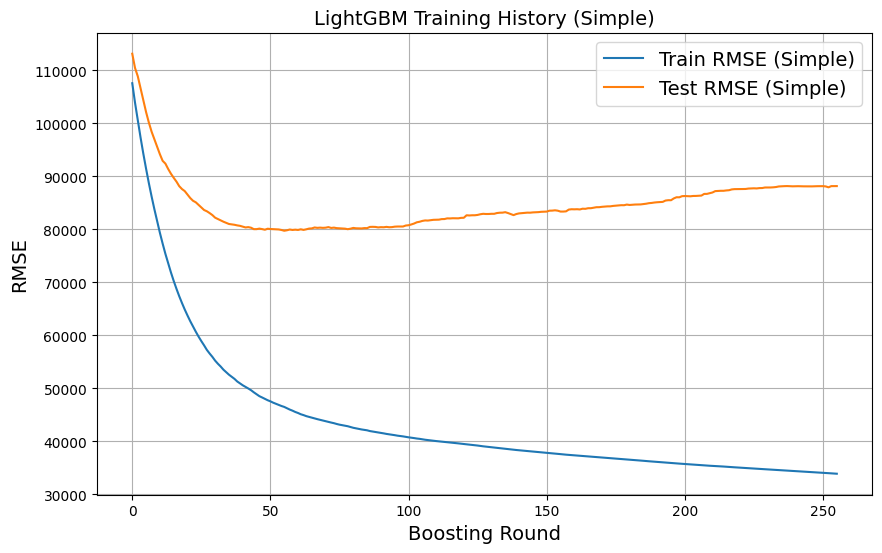

In [145]:
# Plot for the simple model
plt.figure(figsize=(10, 6))
plt.plot(evals_result_simple['training']['rmse'], label='Train RMSE (Simple)')
plt.plot(evals_result_simple['valid_1']['rmse'], label='Test RMSE (Simple)')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('LightGBM Training History (Simple)')
plt.legend()
plt.grid(True)
plt.show()


# 7. ตัวอย่างเพิ่มเติมการ Tune พารามิเตอร์ในโมเดล

## 7.1 Grid Search

### 7.1.1 การใช้ GridSearch

**หมายเหตุ:**  เซลล์ต่อไปนี้อาจใช้เวลาในการดำเนินการนานสักระยะ 7-15 นาที

In [146]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b50a002c0d0>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

### 7.1.2 การเลือก full tune

คุณสามารถดูรายการไฮเปอร์พารามิเตอร์ทั้งหมดที่พร้อมสำหรับการปรับแต่งได้โดยดูที่ `full_pipeline.get_params().keys()`:

In [147]:
# extra code – shows part of the output of get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

### 7.1.3 การหา parameters ที่ดีที่สุด

In [148]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [149]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7b509bd...
                                                  ClusterSimilarity(n_clusters=15,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7b508dfac670>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

### 7.1.4 ดูการทำงานของ GridSearch

Let's look at the score of each hyperparameter combination tested during the grid search:

In [150]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,41740,43331,41722,42264
13,15,8,42218,43312,42359,42630
6,10,4,42555,43939,42684,43059
14,15,10,42661,43973,42755,43130
7,10,6,42758,44077,43052,43296


### 7.1.5 ประเมินโมเดล (trainset)

In [151]:
# Random Forest + GridSearch
housing_predictions_forest = forest_reg.predict(housing)
print(f'Forest with out tune [:5]:{housing_predictions_forest[:5].round(-2)}')  # -2 = rounded to the nearest hundred

housing_predictions_forest_gt = grid_search.predict(housing)
print(housing_predictions_forest_gt.shape)
print(f'Forest with grid tune [:5]:{housing_predictions_forest_gt[:5].round(-2)}')  # -2 = rounded to the nearest hundred

print(f'real value [:5]: {housing_labels.iloc[:5].values}')

Forest with out tune [:5]:[340200.  85100. 164400. 171200.  86200.]
(14448,)
Forest with grid tune [:5]:[466200. 104100.  99200. 345200. 107300.]
real value [:5]: [483800. 101700.  96100. 361800.  92600.]


### 7.1.6 ประเมินโมเดล (testset)

In [152]:

# Evaluate the Random Forest model (without tuning) on the test set
housing_predictions_forest_test = forest_reg.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_forest_test)
print(f'Random Forest Regression (testset, without tuning):\n mae={mae:.2f}, mse={mse:.2f}, rmse={rmse:.2f}, r_squared={r_squared:.2f}')
print(housing_predictions_forest_test.shape)
# Evaluate the Random Forest model (with tuning) on the test set
housing_predictions_forest_test_t = forest_search.predict(housing_test)
mae, mse, rmse, r_squared = evaluation(housing_labels_test, housing_predictions_forest_test_t)
print(f'Random Forest Regression (testset, with tuning):\n mae={mae:.2f}, mse={mse:.2f}, rmse={rmse:.2f}, r_squared={r_squared:.2f}')

Random Forest Regression (testset, without tuning):
 mae=57558.44, mse=6773804313.95, rmse=82303.12, r_squared=0.49
(4128,)
Random Forest Regression (testset, with tuning):
 mae=39251.49, mse=3227567702.89, rmse=56811.69, r_squared=0.76


# 8. สรุปผลโมเดล

## 8.1 ฟังก์ชั่นในการสรุปผล

In [153]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,precision_score,recall_score,f1_score,precision_recall_curve,confusion_matrix
from sklearn.model_selection import cross_val_score,cross_val_predict,learning_curve

def plot_learning_curve(model, title, X, y, ax):
    train_sizes, train_scores, valid_scores = learning_curve(
        model, X, y, train_sizes=np.linspace(0.01, 1.0, 10), cv=10,
        scoring="neg_root_mean_squared_error"
    )
    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)
    ax.set_title(title)
    ax.plot(train_sizes, train_errors, "r-.", linewidth=2, label="train")
    ax.plot(train_sizes, valid_errors, "g-", linewidth=3, label="valid")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("RMSE")
    ax.grid()
    ax.legend(loc="upper right")

def cv_result(model,param1,param2):
  cv_res = pd.DataFrame(model.cv_results_)
  cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

  cv_res = cv_res[[param1,
                  param2, "split0_test_score",
                  "split1_test_score", "split2_test_score", "mean_test_score"]]
  score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
  cv_res.columns = [param1, param2] + score_cols
  cv_res[score_cols] = -cv_res[score_cols].round()
  display(cv_res.head())

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared


## 8.2 การดูการทำงานของทุกโมเดล

In [154]:
models_evaluate = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score"])
models_evaluate_test = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score"])

model_order = [lin_reg, linreg_search,
               ridge_reg, ridge_search,
               lasso_reg, lasso_search,
               elastic_reg, elastic_search,
               tree_reg, tree_search,
               forest_reg, forest_search,
               grid_search,
               ]

model_name_order = ['LinearRegression', 'LinearRegression_tune',
               'Ridge', 'Ridge_tune',
               'Lasso', 'Lasso_tune',
               'ElasticNet', 'ElasticNet_tune',
               'DecisionTreeRegressor', 'DecisionTreeRegressor_tune',
               'RandomForestRegressor', 'RandomForestRegressor_tune',
               'RandomForestRegressor_grid_tune',
               'LightGBMRegressor', 'LightGBMRegressor_tune']



## trainset evaluation
for model_name, model in zip(model_name_order,model_order):
  mae, mse, rmse, r_squared = evaluation(housing_labels,
                                         model.predict(housing))
  print(model_name)
  new_row = {"Model": model_name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r_squared}
  print(new_row)

  models_evaluate = pd.concat([models_evaluate, pd.DataFrame([new_row])], ignore_index=True)

## testset evaluation
for model_name, model in zip(model_name_order,model_order):
  mae, mse, rmse, r_squared = evaluation(housing_labels_test,
                                         model.predict(housing_test))
  print(model_name)
  new_row = {"Model": model_name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2 Score": r_squared}
  print(new_row)

  models_evaluate_test = pd.concat([models_evaluate_test, pd.DataFrame([new_row])], ignore_index=True)

LinearRegression
{'Model': 'LinearRegression', 'MAE': 92992.93944915297, 'MSE': 12905755393.41639, 'RMSE': 113603.5007973627, 'R2 Score': -0.03874030092080294}
LinearRegression_tune
{'Model': 'LinearRegression_tune', 'MAE': 48925.00760032987, 'MSE': 4334447302.234981, 'RMSE': 65836.51951793153, 'R2 Score': 0.6511350976521904}
Ridge
{'Model': 'Ridge', 'MAE': 92193.38102709365, 'MSE': 12704552548.16001, 'RMSE': 112714.4735522462, 'R2 Score': -0.022546169104671554}
Ridge_tune
{'Model': 'Ridge_tune', 'MAE': 49557.46095569265, 'MSE': 4426868701.488634, 'RMSE': 66534.71801615029, 'R2 Score': 0.6436964139683794}
Lasso
{'Model': 'Lasso', 'MAE': 92819.9822341067, 'MSE': 12862238598.945744, 'RMSE': 113411.80978604364, 'R2 Score': -0.03523778233079411}
Lasso_tune
{'Model': 'Lasso_tune', 'MAE': 50004.10297921369, 'MSE': 4491875863.895921, 'RMSE': 67021.45823462751, 'R2 Score': 0.6384642088488404}
ElasticNet
{'Model': 'ElasticNet', 'MAE': 62741.122305544704, 'MSE': 6840114227.889691, 'RMSE': 82704.

In [155]:
models_evaluate_sorted = models_evaluate.sort_values(by="RMSE", ascending=True)
models_evaluate_sorted

,Model,MAE,MSE,RMSE,R2 Score
9,DecisionTreeRegressor_tune,0.000000,0.000000e+00,0.000000,1.000000
12,RandomForestRegressor_grid_tune,9734.966796,2.357035e+08,15352.638202,0.981029
11,RandomForestRegressor_tune,35033.040154,2.496497e+09,49964.955878,0.799065
1,LinearRegression_tune,48925.007600,4.334447e+09,65836.519518,0.651135
3,Ridge_tune,49557.460956,4.426869e+09,66534.718016,0.643696
5,Lasso_tune,50004.102979,4.491876e+09,67021.458235,0.638464
10,RandomForestRegressor,56383.482995,6.604537e+09,81268.301321,0.468423
6,ElasticNet,62741.122306,6.840114e+09,82704.983090,0.449462
7,ElasticNet_tune,86142.178144,1.204849e+10,109765.616590,0.030258
8,DecisionTreeRegressor,80083.828765,1.242959e+10,111488.079378,-0.000416


## 8.3 พล็อตโมเดลที่ดีที่สุด

### 8.3.1 MAE

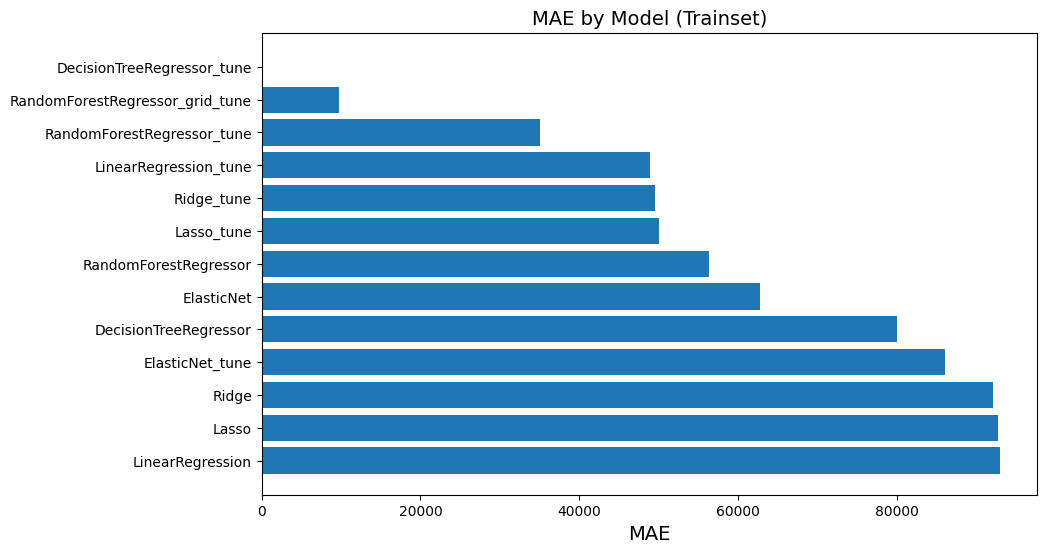

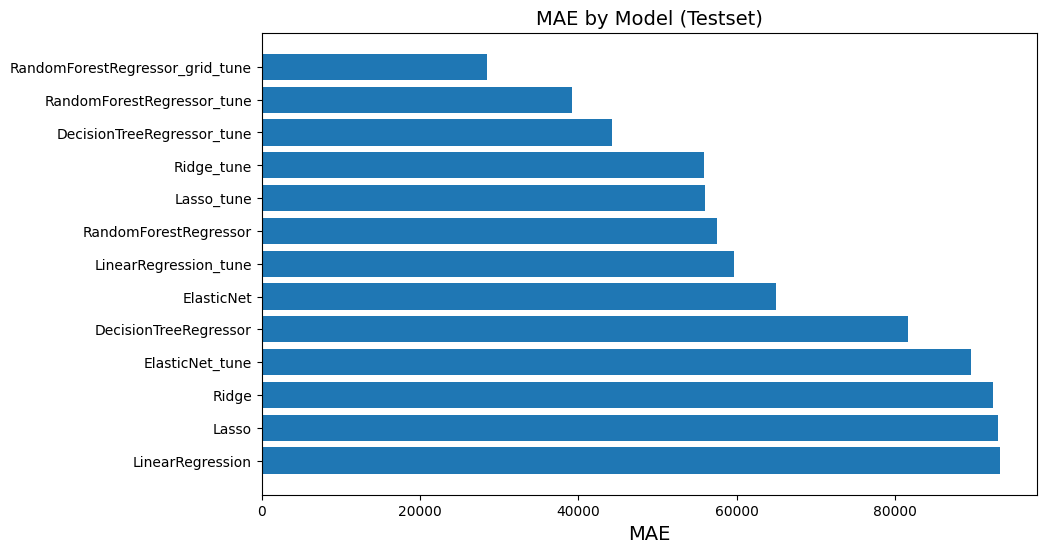

In [156]:
# Sort models by MAE for trainset
models_evaluate_sorted_mae = models_evaluate.sort_values(by="MAE", ascending=True)

# Create the plot for MAE (trainset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_sorted_mae["Model"], models_evaluate_sorted_mae["MAE"])
plt.xlabel("MAE")
plt.title("MAE by Model (Trainset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

# Sort models by MAE for testset
models_evaluate_test_sorted_mae = models_evaluate_test.sort_values(by="MAE", ascending=True)

# Create the plot for MAE (testset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_test_sorted_mae["Model"], models_evaluate_test_sorted_mae["MAE"])
plt.xlabel("MAE")
plt.title("MAE by Model (Testset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

### 8.3.2 MSE

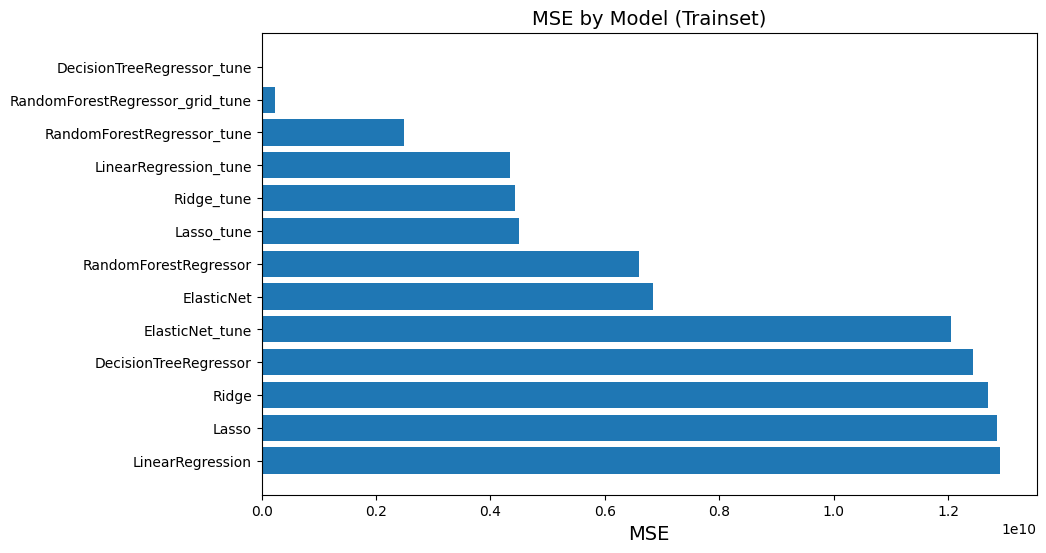

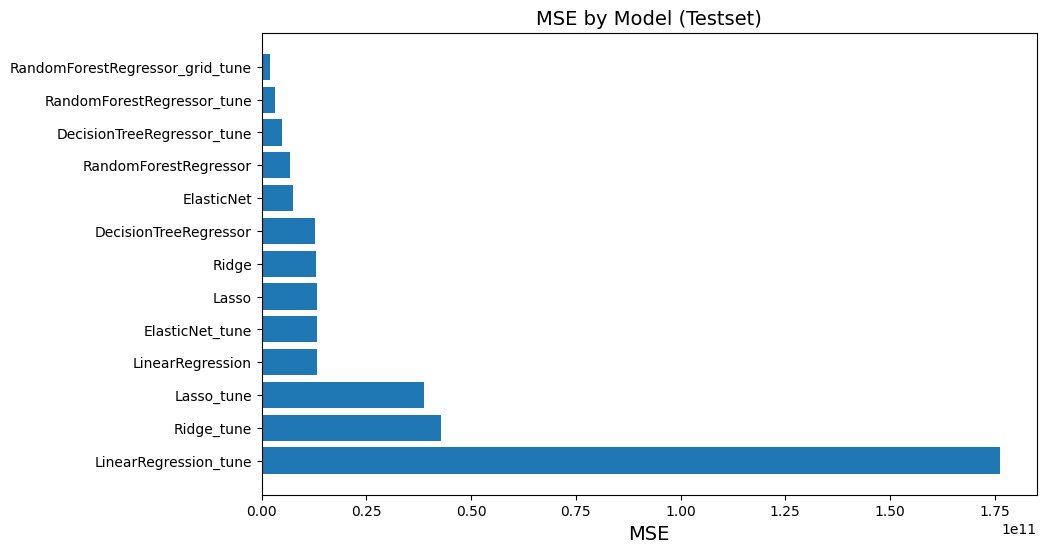

In [157]:


# Sort models by MSE for trainset
models_evaluate_sorted_mse = models_evaluate.sort_values(by="MSE", ascending=True)

# Create the plot for MSE (trainset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_sorted_mse["Model"], models_evaluate_sorted_mse["MSE"])
plt.xlabel("MSE")
plt.title("MSE by Model (Trainset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

# Sort models by MSE for testset
models_evaluate_test_sorted_mse = models_evaluate_test.sort_values(by="MSE", ascending=True)

# Create the plot for MSE (testset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_test_sorted_mse["Model"], models_evaluate_test_sorted_mse["MSE"])
plt.xlabel("MSE")
plt.title("MSE by Model (Testset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

### 8.3.3 RMSE

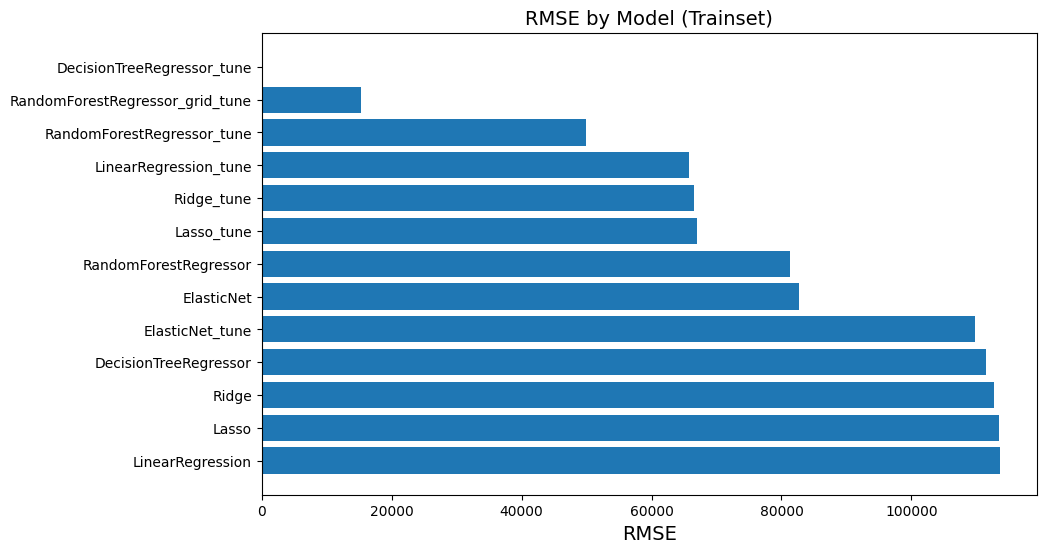

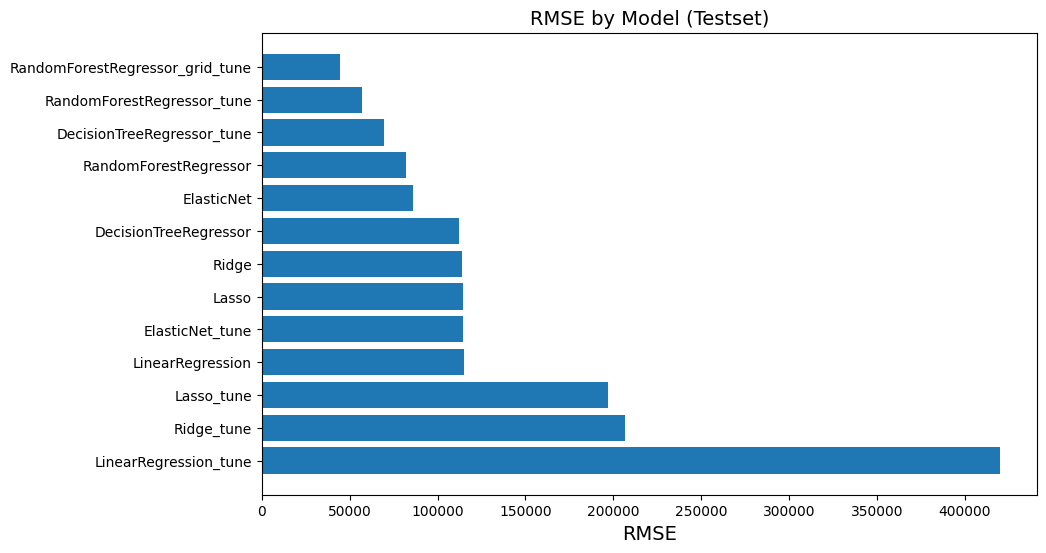

In [158]:
# Sort models by RMSE for trainset
models_evaluate_sorted_rmse = models_evaluate.sort_values(by="RMSE", ascending=True)

# Create the plot for RMSE (trainset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_sorted_rmse["Model"], models_evaluate_sorted_rmse["RMSE"])
plt.xlabel("RMSE")
plt.title("RMSE by Model (Trainset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

# Sort models by RMSE for testset
models_evaluate_test_sorted_rmse = models_evaluate_test.sort_values(by="RMSE", ascending=True)

# Create the plot for RMSE (testset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_test_sorted_rmse["Model"], models_evaluate_test_sorted_rmse["RMSE"])
plt.xlabel("RMSE")
plt.title("RMSE by Model (Testset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

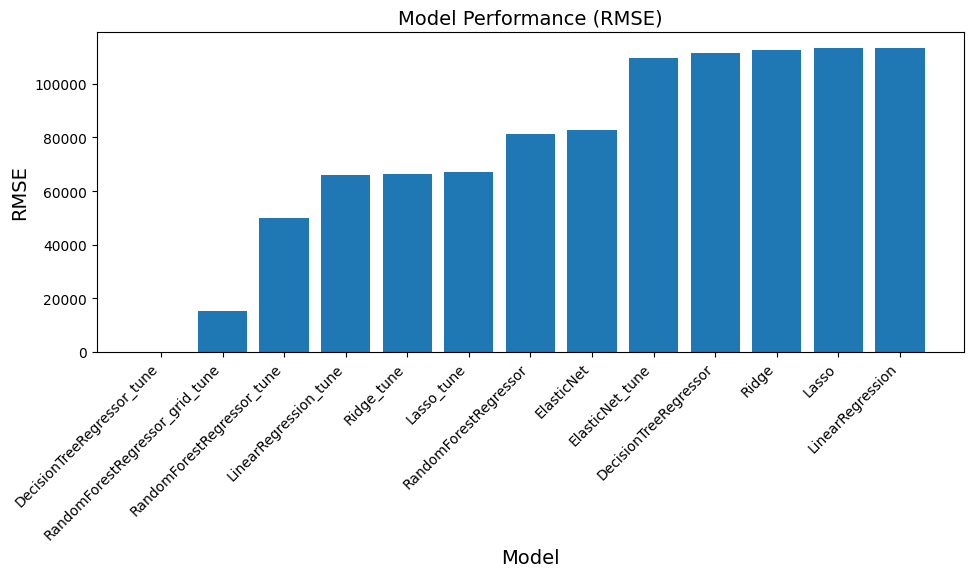

In [159]:
models_evaluate_sorted = models_evaluate.sort_values(by="RMSE", ascending=True)

plt.figure(figsize=(10, 6))
plt.bar(models_evaluate_sorted["Model"], models_evaluate_sorted["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Performance (RMSE)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### 8.3.4 R Square

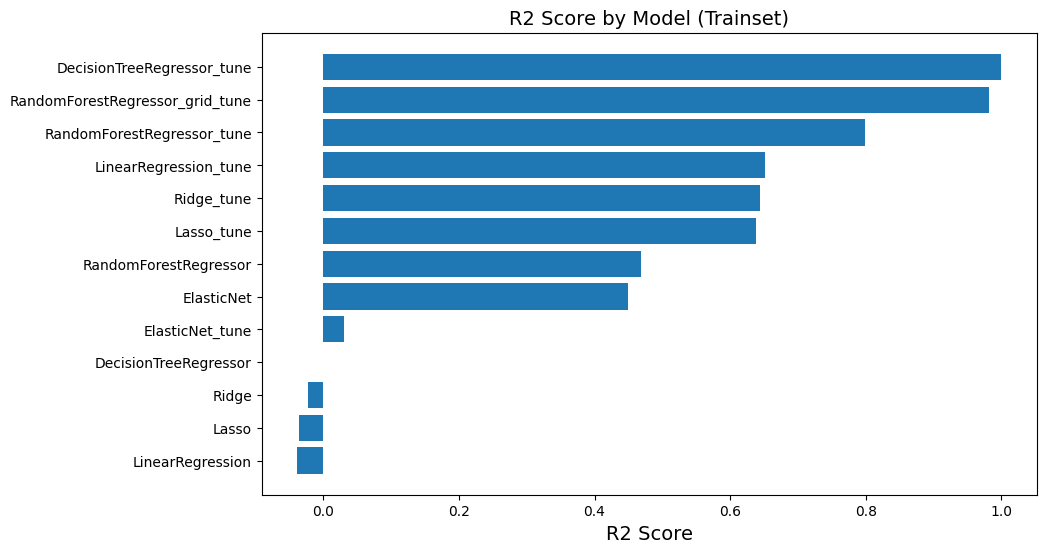

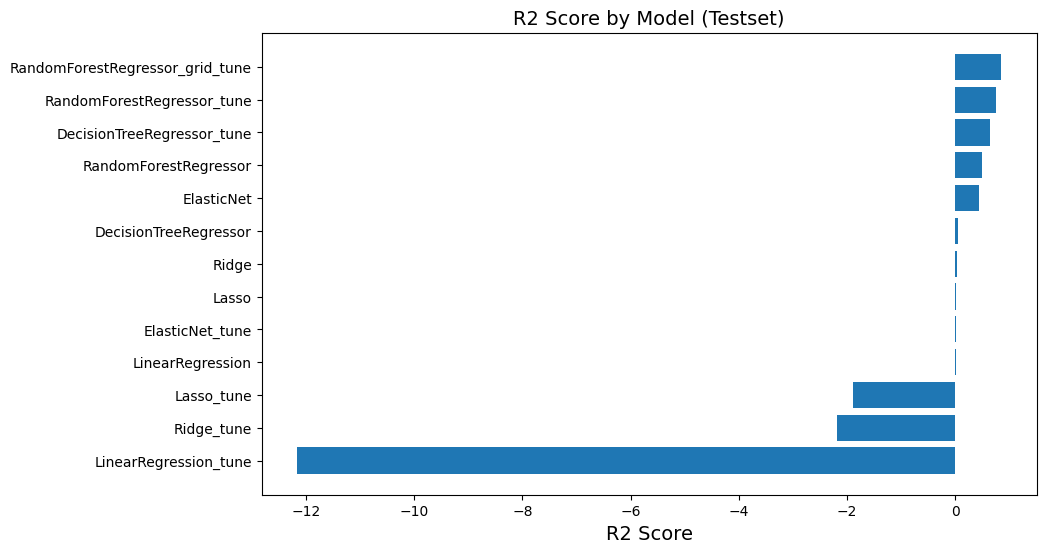

In [160]:
# Sort the DataFrames by R2 Score
models_evaluate_sorted = models_evaluate.sort_values(by="R2 Score", ascending=False)
models_evaluate_test_sorted = models_evaluate_test.sort_values(by="R2 Score", ascending=False)

# Create the plot for R2 Score (trainset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_sorted["Model"], models_evaluate_sorted["R2 Score"])
plt.xlabel("R2 Score")
plt.title("R2 Score by Model (Trainset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

# Create the plot for R2 Score (testset)
plt.figure(figsize=(10, 6))
plt.barh(models_evaluate_test_sorted["Model"], models_evaluate_test_sorted["R2 Score"])
plt.xlabel("R2 Score")
plt.title("R2 Score by Model (Testset)")
plt.gca().invert_yaxis()  # Invert y-axis to display best performing models at the top
plt.show()

## 8.4 การดู Learning Curve

**หมายเหตุ:**  เซลล์ต่อไปนี้อาจใช้เวลาในการดำเนินการนานสักระยะ 3 ชม.

ValueError: 
All the 100 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 1189, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 955, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py", line 282, in train
    booster = Booster(params=params, train_set=train_set)
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/basic.py", line 3637, in __init__
    train_set.construc

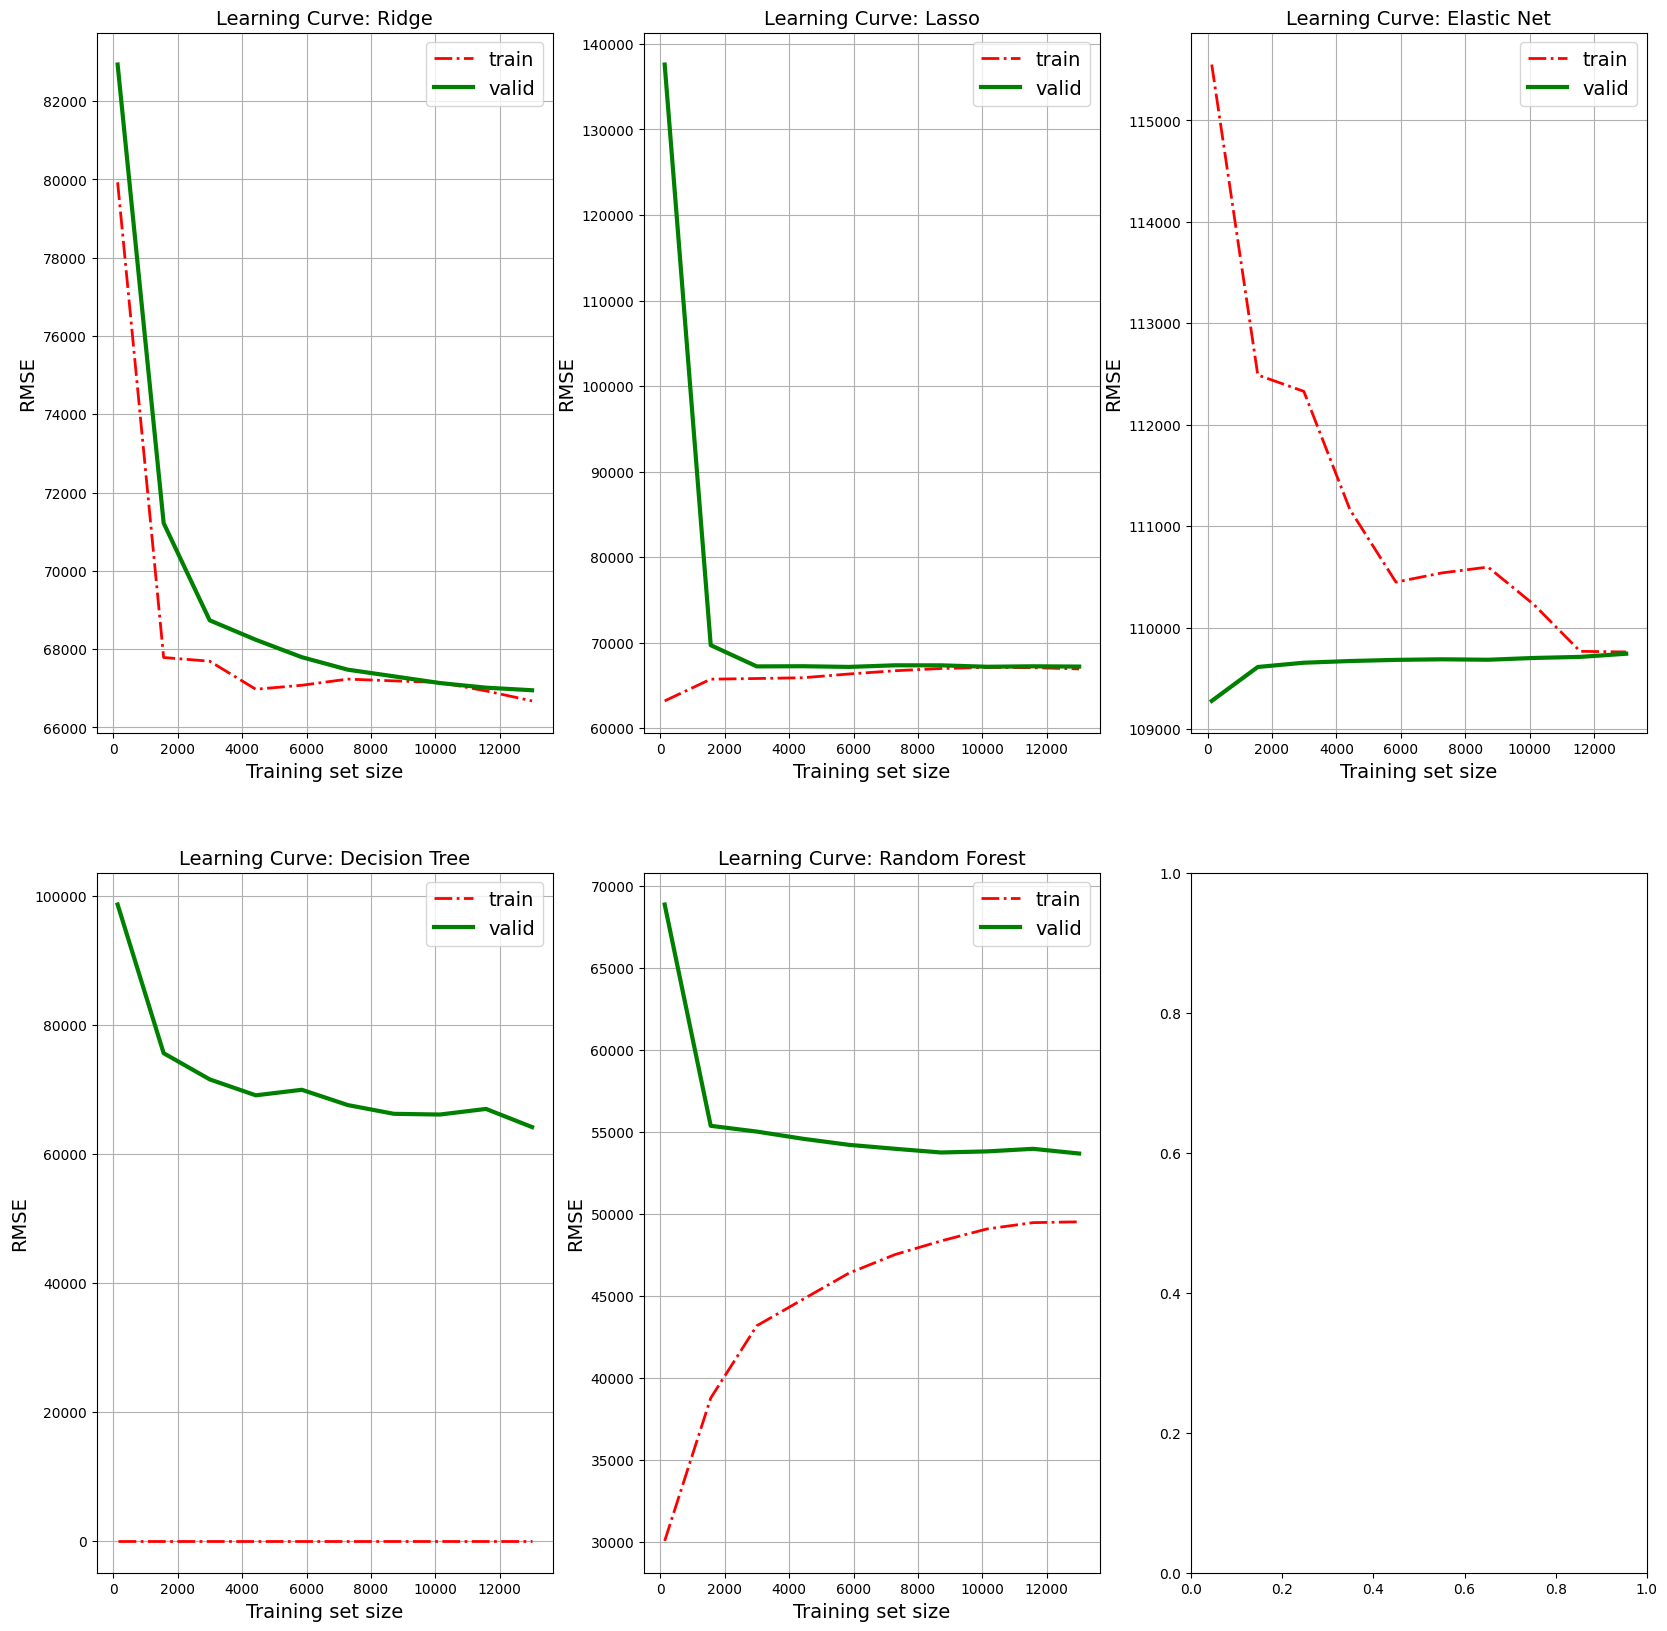

In [161]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 20))
axes = axes.flatten() # convert to 1D array

# Assuming you have your models (ridge_search, lasso_search, etc.) and data (X, y) available.
models = [ridge_search, lasso_search, elastic_search, tree_search, forest_search, light_search]
model_names = ["Ridge", "Lasso", "Elastic Net", "Decision Tree", "Random Forest", "LightGBM"]


for i, (model, model_name) in enumerate(zip(models, model_names)):
    plot_learning_curve(model.best_estimator_, f"Learning Curve: {model_name}", housing, housing_labels, axes[i])

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

# 9. Save โมเดล ด้วยกาารใช้ joblib

## 9.1 Save final model:

In [ ]:
import joblib

joblib.dump(grid_search, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

## 9.2 โหลดโมเดล

สามารถนำโมเดลนี้ไปใช้งานจริงได้ในขณะนี้ ตัวอย่างเช่น โค้ดต่อไปนี้จะเป็นสคริปต์ที่รันในระบบการผลิต
- คุณสามารถใช้ pickle แทนได้ แต่ joblib มีประสิทธิภาพมากกว่า

In [ ]:
import joblib

# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel


final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

In [ ]:
predictions

array([430661.09, 463568.15, 105374.  ,  97438.  , 345196.08])

# Appendix

## A. การเลือกค่าแจกแจงเเบบสุ่ม

**ส่วนโบนัส: วิธีเลือกการแจกแจงแบบสุ่มสำหรับไฮเปอร์พารามิเตอร์**




* `scipy.stats.randint(a, b+1)`: สำหรับไฮเปอร์พารามิเตอร์ที่มีค่า ไม่ต่อเนื่อง ตั้งแต่ a ถึง b และค่าทั้งหมดในช่วงนั้นมีความน่าจะเป็นเท่ากัน
* `scipy.stats.geom(1 / scale)`: สำหรับค่าไม่ต่อเนื่อง เมื่อคุณต้องการสุ่มตัวอย่างโดยประมาณในสเกลที่กำหนด ตัวอย่างเช่น ด้วย scale=1000 ตัวอย่างส่วนใหญ่จะอยู่ในช่วงนี้ แต่ประมาณ 10% ของตัวอย่างทั้งหมดจะมีค่า <100 และประมาณ 10% จะมีค่า >2300
* `scipy.stats.expon(scale)`: นี่คือค่าเทียบเท่าแบบต่อเนื่องของ `geom`เพียงแค่ตั้งค่า`scale`  เป็นค่าที่น่าจะเป็นไปได้มากที่สุด
* `scipy.stats.loguniform(a, b)`: เมื่อคุณแทบไม่มีความคิดใดๆ เกี่ยวกับสเกลของค่าไฮเปอร์พารามิเตอร์ที่เหมาะสมที่สุด หากคุณตั้งค่า a=0.01 และ b=100 คุณมีความเป็นไปได้เท่ากันที่จะสุ่มตัวอย่างค่าระหว่าง 0.01 ถึง 0.1 เช่นเดียวกับค่าระหว่าง 10 ถึง 100


นี่คือกราฟของฟังก์ชันมวลความน่าจะเป็น (สำหรับตัวแปรแบบไม่ต่อเนื่อง) และฟังก์ชันความหนาแน่นของความน่าจะเป็น (สำหรับตัวแปรแบบต่อเนื่อง) สำหรับ `randint()`, `uniform()`, `geom()` and `expon()`:

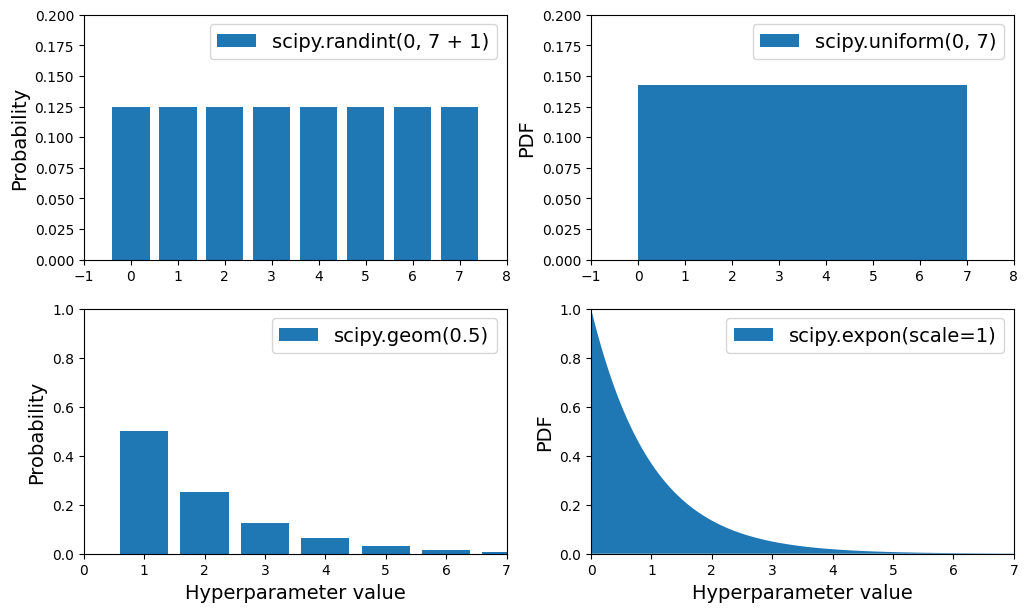

In [ ]:
# extra code – plots a few distributions you can use in randomized search

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

## B. การวิเคราะห์โมเดลที่ดีที่สุด และค่า errors
โดยทั่วไปแล้ว ค่า feature_importances ที่สูงบ่งบอกว่าคุณลักษณะนั้นมีความสำคัญต่อการทำนายผลลัพธ์สูง นั่นหมายความว่า เมื่อค่าของคุณลักษณะนั้นเปลี่ยนแปลงไป จะส่งผลให้ผลลัพธ์ที่โมเดลทำนายได้เปลี่ยนแปลงไปอย่างมีนัยสำคัญ



In [ ]:
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

In [ ]:
final_model = grid_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
print(feature_importances.shape)
feature_importances.round(2)

(29,)


array([0.06, 0.05, 0.07, 0.01, 0.01, 0.01, 0.01, 0.24, 0.02, 0.03, 0.02,
       0.03, 0.04, 0.02, 0.04, 0.03, 0.02, 0.04, 0.02, 0.02, 0.03, 0.03,
       0.02, 0.01, 0.1 , 0.  , 0.  , 0.01, 0.02])

In [ ]:
 sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(0.2358975739238613, 'log__median_income'),
 (0.10289135078579176, 'cat__ocean_proximity_INLAND'),
 (0.07222418797006476, 'people_per_house__ratio'),
 (0.05904967837082689, 'bedrooms__ratio'),
 (0.04528061979623596, 'rooms_per_house__ratio'),
 (0.04323586020010948, 'geo__Cluster 4 similarity'),
 (0.03918315369529593, 'geo__Cluster 9 similarity'),
 (0.0382453924816579, 'geo__Cluster 6 similarity'),
 (0.031494672724036436, 'geo__Cluster 12 similarity'),
 (0.028862862470161375, 'geo__Cluster 13 similarity'),
 (0.027990949389268726, 'geo__Cluster 3 similarity'),
 (0.026342368828708097, 'geo__Cluster 7 similarity'),
 (0.025888877938702662, 'geo__Cluster 1 similarity'),
 (0.02434109787774532, 'geo__Cluster 14 similarity'),
 (0.022790255807667626, 'geo__Cluster 11 similarity'),
 (0.022631444517123015, 'geo__Cluster 5 similarity'),
 (0.021444208532414286, 'geo__Cluster 0 similarity'),
 (0.02092092400550801, 'geo__Cluster 10 similarity'),
 (0.020167042417287576, 'geo__Cluster 8 similarity'),
 

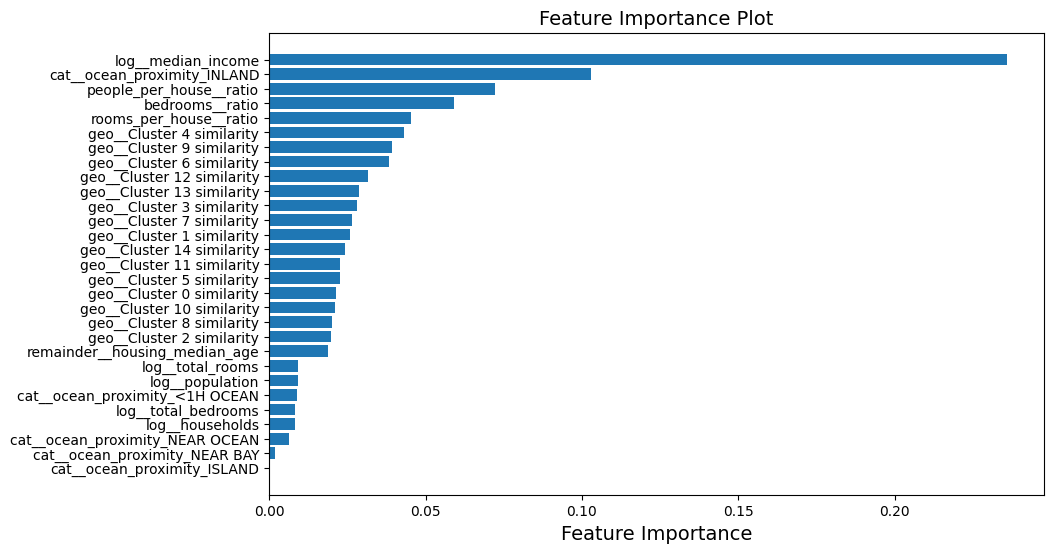

In [ ]:
feature_importances = final_model["random_forest"].feature_importances_
feature_names = final_model["preprocessing"].get_feature_names_out()

# Create a dictionary to store feature importances
feature_importance_dict = dict(zip(feature_names, feature_importances))


# Sort feature importances in descending order
sorted_feature_importances = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Extract feature names and importances for plotting
feature_names_sorted = [feature for feature, importance in sorted_feature_importances]
feature_importances_sorted = [importance for feature, importance in sorted_feature_importances]

# Create the plot
plt.figure(figsize=(10, 6))
plt.barh(feature_names_sorted, feature_importances_sorted)
plt.xlabel("Feature Importance")
plt.title("Feature Importance Plot")
plt.gca().invert_yaxis()  # Invert y-axis to display most important features at the top
plt.show()

## C. การประเมินโมเดลด้วยค่าความมั่นใจ 95%

In [ ]:
from scipy import stats

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(final_rmse)

44255.048009437705


เราสามารถหาช่วงความเชื่อมั่น 95% ของค่า RMSE ในชุดทดสอบได้

In [ ]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([42107.42726032, 46303.16531461])

## D. การใช้ Error Analysis (Scatter)

In [ ]:
# Error analysis
errors = None
error_df = None

errors = housing_predictions_forest_gt - housing_labels
errors_test = housing_predictions_forest_test_t - housing_labels_test

# Create a DataFrame for error analysis
error_df = pd.DataFrame({'Prediction': housing_predictions_forest_gt, 'Actual': housing_labels, 'Error': errors})
error_df_test = pd.DataFrame({'Prediction': housing_predictions_forest_test_t, 'Actual': housing_labels_test, 'Error': errors_test})

print(error_df.shape)
print(error_df_test.shape)
error_df.head()



(14448, 3)
(4128, 3)


,Prediction,Actual,Error
14973,466235.08,483800.0,-17564.92
3785,104067.00,101700.0,2367.00
14689,99211.00,96100.0,3111.00
20507,345160.03,361800.0,-16639.97
1286,107347.00,92600.0,14747.00


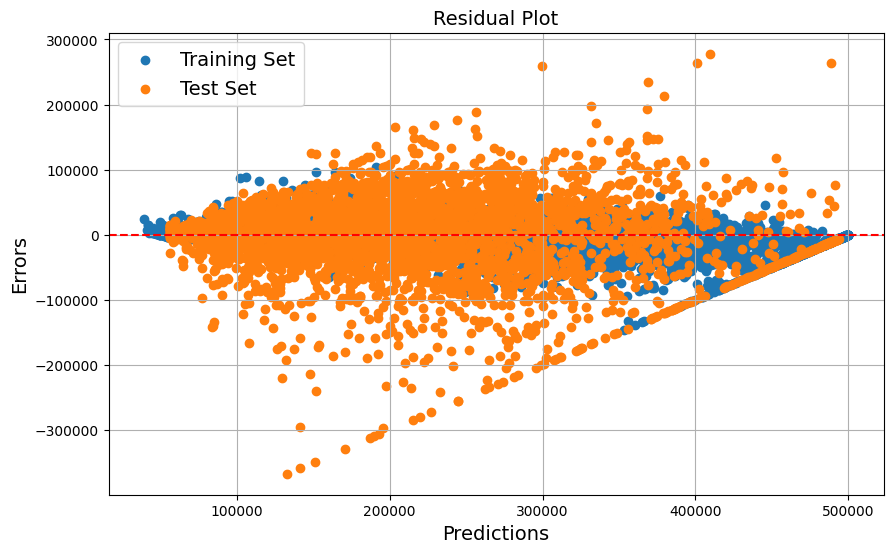

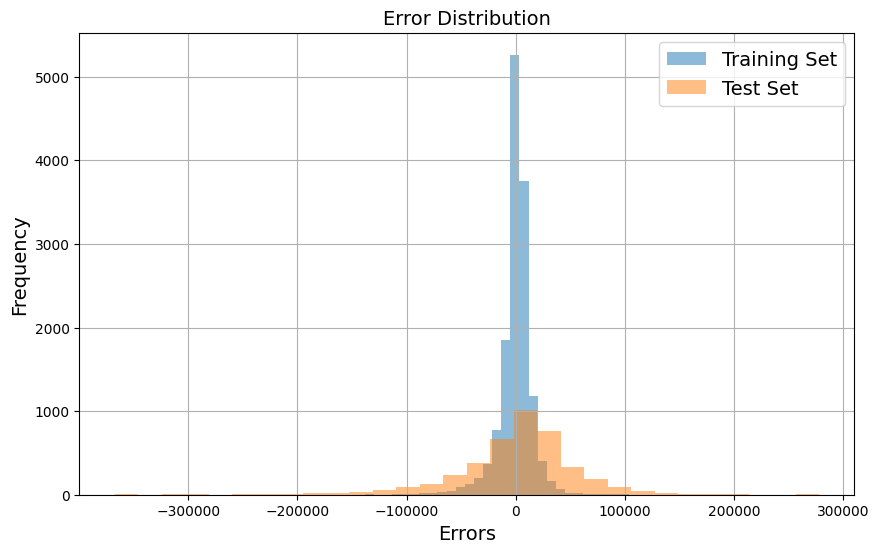

In [ ]:
# Plotting the residuals (errors)
plt.figure(figsize=(10, 6))
plt.scatter(housing_predictions_forest_gt, errors, label='Training Set')
plt.scatter(housing_predictions_forest_test_t, errors_test, label='Test Set')
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.xlabel("Predictions")
plt.ylabel("Errors")
plt.title("Residual Plot")
plt.legend()
plt.grid()
plt.show()


# Plotting error distribution
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, alpha=0.5, label='Training Set')
plt.hist(errors_test, bins=30, alpha=0.5, label='Test Set')
plt.xlabel("Errors")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Example: Examining specific instances with large errors
large_errors_df = error_df[abs(error_df['Error']) > 100000] # Example threshold
large_errors_df =pd.DataFrame(large_errors_df)
print(large_errors_df.shape)
large_errors_df


(13, 3)


,Prediction,Actual,Error
13630,365162.00,500000.0,-134838.00
4486,360461.57,500001.0,-139539.43
7150,390269.69,500001.0,-109731.31
11939,353164.58,500001.0,-146836.42
1783,394491.63,500001.0,-105509.37
8042,399597.67,500001.0,-100403.33
875,396493.60,500001.0,-103507.40
1023,366508.53,500001.0,-133492.47
15868,391411.00,500000.0,-108589.00
17538,397265.64,500001.0,-102735.36


large error shape :(13, 3)
error shape :(14448, 3)


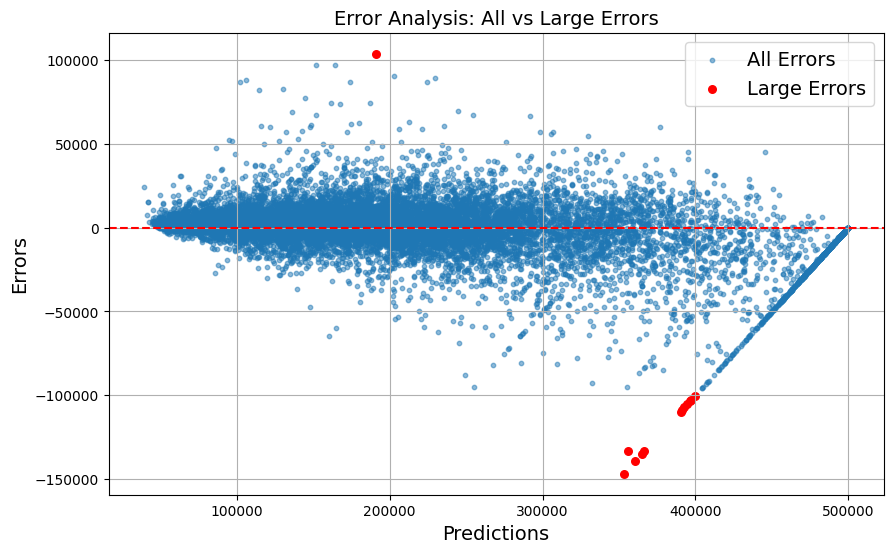

In [ ]:
# Plotting large errors vs. all errors
print(f'large error shape :{large_errors_df.shape}')
print(f'error shape :{error_df.shape}')

plt.figure(figsize=(10, 6))
plt.scatter(error_df['Prediction'], error_df['Error'], label='All Errors', alpha=0.5, s=10)  # Plot all errors
plt.scatter(large_errors_df['Prediction'], large_errors_df['Error'], color='red', label='Large Errors', s=30) #Plot large errors in red
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predictions")
plt.ylabel("Errors")
plt.title("Error Analysis: All vs Large Errors")
plt.legend()
plt.grid(True)
plt.show()

All good! That's all for today! 😀

Congratulations! You already know quite a lot about Machine Learning. :)